# ДЗ 1: классификация новостей Lenta.ru по топикам

задача - классифицировать тексты новостей по рубрикам (topic). данные берем из датасета lenta-ru-news через библиотеку Corus (~800k статей).

будем использовать LogisticRegression с разными способами векторизации текста (CountVectorizer и TfidfVectorizer), потом подберем гиперпараметры.

## 0. установка зависимостей и импорты

In [1]:
%pip install corus pymorphy3 scikit-learn pandas numpy matplotlib seaborn nltk tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import pymorphy3
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline

from corus import load_lenta

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


## 1. загрузка данных

скачиваем датасет lenta-ru-news и грузим через библиотеку [Corus](https://github.com/natasha/corus). нам нужны поля `title`, `text` и `topic`.

In [3]:
DATA_PATH = 'lenta-ru-news.csv.gz'

!curl -L -o {DATA_PATH} https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz
print(f'размер файла: {os.path.getsize(DATA_PATH) / 1024 / 1024:.1f} MB')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:29 --:--:--     000:22 --:--:--     0  0 --:--:--  0:00:26 --:--:--     0curl: (6) Could not resolve host: github.com
размер файла: 502.9 MB


In [4]:
records = load_lenta(DATA_PATH)

data = []
for record in tqdm(records, desc='Загрузка записей'):
    data.append({
        'title': record.title,
        'text': record.text,
        'topic': record.topic,
    })

df = pd.DataFrame(data)
print(f'Размер датасета: {df.shape}')
df.head()

Загрузка записей: 0it [00:00, ?it/s]

Размер датасета: (739351, 3)


,title,text,topic
0,Названы регионы России с самой высокой смертно...,Вице-премьер по социальным вопросам Татьяна Го...,Россия
1,Австрия не представила доказательств вины росс...,Австрийские правоохранительные органы не предс...,Спорт
2,Обнаружено самое счастливое место на планете,Сотрудники социальной сети Instagram проанализ...,Путешествия
3,В США раскрыли сумму расходов на расследование...,С начала расследования российского вмешательст...,Мир
4,Хакеры рассказали о планах Великобритании зами...,Хакерская группировка Anonymous опубликовала н...,Мир


In [5]:
print(f'Всего записей: {len(df)}')
print(f'Уникальных топиков: {df["topic"].nunique()}')
print(f'\nПропуски:')
print(df.isnull().sum())
print(f'\nРаспределение топиков:')
print(df['topic'].value_counts())

Всего записей: 739351
Уникальных топиков: 24

Пропуски:
title    0
text     0
topic    0
dtype: int64

Распределение топиков:
topic
Россия               160519
Мир                  136680
Экономика             79538
Спорт                 64421
Культура              53803
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44675
Из жизни              27611
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
                        203
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: count, dtype: int64


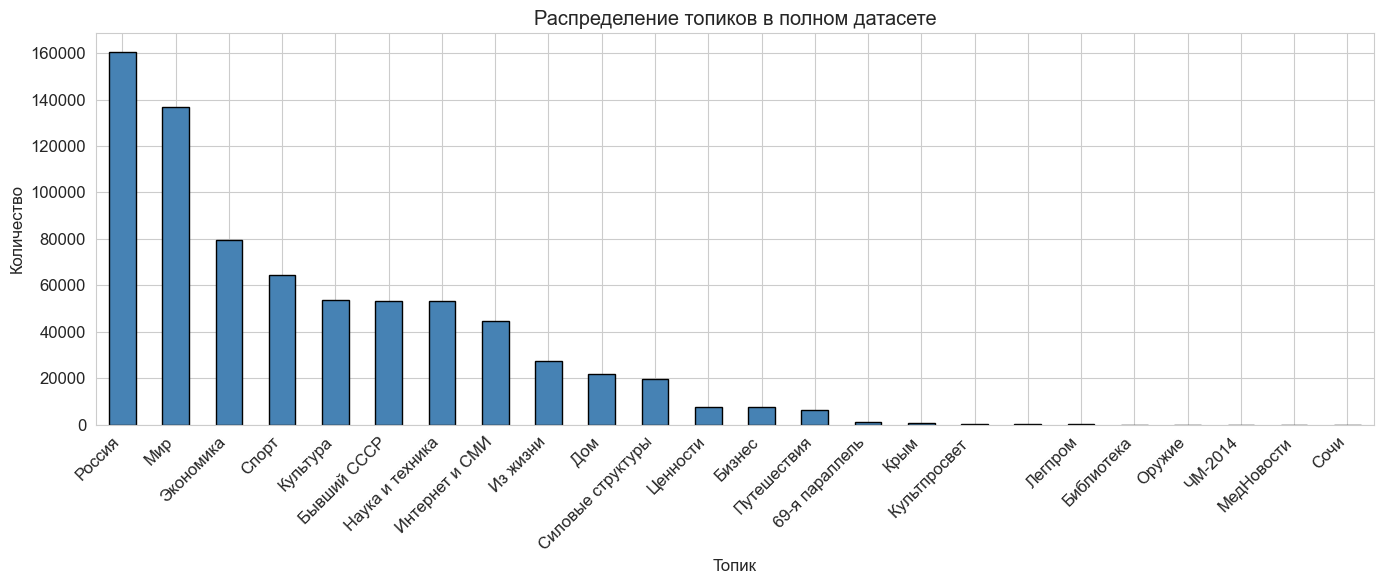

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
topic_counts = df['topic'].value_counts()
topic_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Распределение топиков в полном датасете')
ax.set_xlabel('Топик')
ax.set_ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

739к записей, топиков довольно много. распределение сильно несбалансированное - "Россия" и "Мир" доминируют, а есть совсем маленькие рубрики. это может быть проблемой для классификации, F1 macro будет страдать из-за редких классов.

## 2. подготовка данных

### 2.1 выборка 100k текстов

полный датасет слишком большой, берем 100к записей. используем стратифицированную выборку через `train_test_split` чтобы пропорции классов сохранились. сначала выкинем пустые тексты и совсем редкие топики (меньше 10 записей), иначе stratify упадет.

In [7]:
df = df.dropna(subset=['text', 'topic'])
df = df[df['text'].str.strip().astype(bool)]
print(f'После фильтрации пустых: {len(df)}')

topic_counts = df['topic'].value_counts()
valid_topics = topic_counts[topic_counts >= 10].index
df = df[df['topic'].isin(valid_topics)]
print(f'После фильтрации редких топиков (< 10 записей): {len(df)}')

SAMPLE_SIZE = 100_000

df_sample, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['topic'],
)
df_sample = df_sample.reset_index(drop=True)
print(f'\nРазмер выборки: {len(df_sample)}')
print(f'Уникальных топиков: {df_sample["topic"].nunique()}')

После фильтрации пустых: 739346
После фильтрации редких топиков (< 10 записей): 739339

Размер выборки: 100000
Уникальных топиков: 20


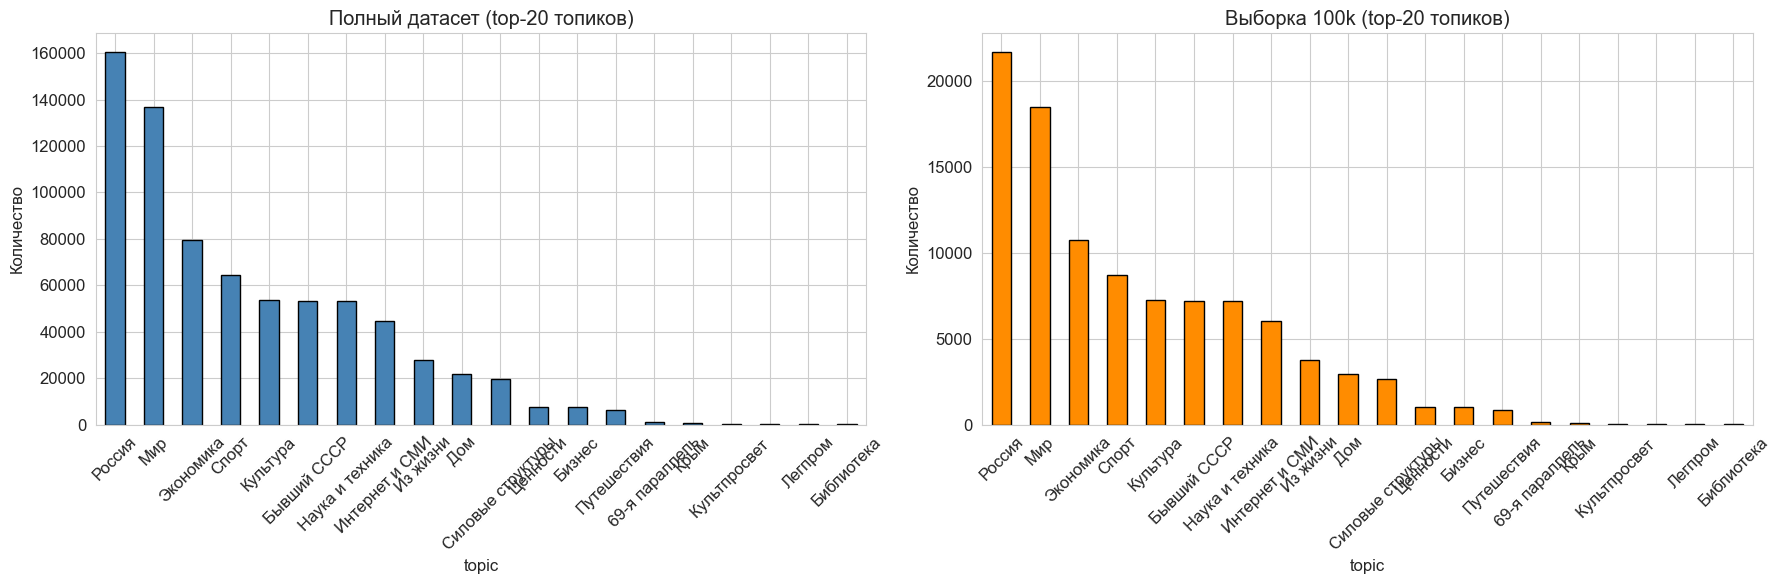

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df['topic'].value_counts().head(20).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Полный датасет (top-20 топиков)')
axes[0].set_ylabel('Количество')

df_sample['topic'].value_counts().head(20).plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='black'
)
axes[1].set_title('Выборка 100k (top-20 топиков)')
axes[1].set_ylabel('Количество')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.2 предобработка текстов

пайплайн, на котором остановился:
1. склеиваю title + text - в заголовке часто есть ключевые слова
2. lowercase
3. убираю всякий мусор (url, email, html-теги, цифры, спецсимволы)
4. лемматизация через pymorphy3 - выбрал именно лемматизацию а не стемминг, потому что для русского языка она дает более осмысленные формы (стеммер часто режет слова некорректно)
5. убираю стоп-слова (nltk русские) и токены короче 2 символов

для скорости кэширую результаты лемматизации (словарь `_lemma_cache`), потому что одни и теже словоформы встречаются тысячи раз. регулярки тоже предкомпилирую. на 100к текстов отрабатывает ~30 секунд, вполне ок.

In [9]:
morph = pymorphy3.MorphAnalyzer()
STOPWORDS = set(stopwords.words('russian'))

RE_URL = re.compile(r'https?://\S+|www\.\S+')
RE_EMAIL = re.compile(r'\S+@\S+')
RE_HTML = re.compile(r'<[^>]+>')
RE_NON_ALPHA = re.compile(r'[^\u0430-\u044f\u0451a-z\s]')
RE_WHITESPACE = re.compile(r'\s+')

_lemma_cache = {}


def lemmatize_word(word):
    """Лемматизация одного слова с кэшированием."""
    if word not in _lemma_cache:
        _lemma_cache[word] = morph.parse(word)[0].normal_form
    return _lemma_cache[word]


def preprocess_text(text):
    """Полный пайплайн предобработки одного текста."""
    text = text.lower()
    text = RE_URL.sub(' ', text)
    text = RE_EMAIL.sub(' ', text)
    text = RE_HTML.sub(' ', text)
    text = RE_NON_ALPHA.sub(' ', text)
    text = RE_WHITESPACE.sub(' ', text).strip()

    tokens = [
        lemmatize_word(t)
        for t in text.split()
        if t not in STOPWORDS and len(t) > 1
    ]
    return ' '.join(tokens)

In [10]:
%%time
tqdm.pandas(desc='Предобработка текстов')

df_sample['full_text'] = (
    df_sample['title'].fillna('') + ' ' + df_sample['text'].fillna('')
)
df_sample['processed_text'] = df_sample['full_text'].progress_apply(preprocess_text)

print(f'\nПример предобработки:')
print(f'Исходный:    {df_sample["full_text"].iloc[0][:200]}...')
print(f'Обработанный: {df_sample["processed_text"].iloc[0][:200]}...')

Предобработка текстов:   0%|          | 0/100000 [00:00<?, ?it/s]


Пример предобработки:
Исходный:    Сечин представил Путину список спонсоров для  "Крыльев Советов" Вице-премьер Игорь Сечин представил премьер-министру Владимиру Путину список из потенциальных спонсоров футбольного клуба "Крылья Совето...
Обработанный: сечин представить путин список спонсор крыло совет вица премьер игорь сечин представить премьер министр владимир путин список потенциальный спонсор футбольный клуб крыло совет самарский область переда...
CPU times: user 34.5 s, sys: 505 ms, total: 35 s
Wall time: 35 s


In [11]:
empty_count = (df_sample['processed_text'].str.strip() == '').sum()
print(f'пустых текстов после предобработки: {empty_count}')

print(f'\nстатистика длины обработанных текстов (в токенах):')
token_counts = df_sample['processed_text'].str.split().str.len()
print(token_counts.describe())

пустых текстов после предобработки: 0

статистика длины обработанных текстов (в токенах):
count    100000.000000
mean        137.303100
std          54.952696
min           4.000000
25%         103.000000
50%         130.000000
75%         164.000000
max        5162.000000
Name: processed_text, dtype: float64


### 2.3 разделение на train / val / test (60/20/20)

делаю в два шага: сначала отделяю 60% train, потом оставшиеся 40% пополам на val и test. стратификация по topic чтобы пропорции классов были одинаковые во всех частях.

In [12]:
X = df_sample['processed_text']
y = df_sample['topic']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print(f'Train: {len(X_train):>6} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val:   {len(X_val):>6} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test:  {len(X_test):>6} ({len(X_test)/len(X)*100:.1f}%)')

print(f'\nПроверка стратификации (top-5 топиков, доли):')
for name, subset in [('Full', y), ('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    top5 = subset.value_counts(normalize=True).head(5)
    print(f'  {name:>5}: {dict(top5.round(3))}')

Train:  60000 (60.0%)
Val:    20000 (20.0%)
Test:   20000 (20.0%)

Проверка стратификации (top-5 топиков, доли):
   Full: {'Россия': np.float64(0.217), 'Мир': np.float64(0.185), 'Экономика': np.float64(0.108), 'Спорт': np.float64(0.087), 'Культура': np.float64(0.073)}
  Train: {'Россия': np.float64(0.217), 'Мир': np.float64(0.185), 'Экономика': np.float64(0.108), 'Спорт': np.float64(0.087), 'Культура': np.float64(0.073)}
    Val: {'Россия': np.float64(0.217), 'Мир': np.float64(0.185), 'Экономика': np.float64(0.108), 'Спорт': np.float64(0.087), 'Культура': np.float64(0.073)}
   Test: {'Россия': np.float64(0.217), 'Мир': np.float64(0.185), 'Экономика': np.float64(0.108), 'Спорт': np.float64(0.087), 'Культура': np.float64(0.073)}


## 3. dummy-бейзлайн

для начала посмотрим, какое качество дает тупо предсказание самого частого класса. это нижняя планка, которую нормальная модель должна легко побить. попробую две стратегии - `most_frequent` и `stratified`.

In [13]:
dummy_results = []

for strategy in ['most_frequent', 'stratified']:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)

    val_acc = accuracy_score(y_val, dummy.predict(X_val))
    val_f1 = f1_score(y_val, dummy.predict(X_val), average='macro')

    dummy_results.append({
        'strategy': strategy,
        'val_accuracy': val_acc,
        'val_f1_macro': val_f1,
    })
    print(f'Dummy ({strategy}):')
    print(f'  Val Accuracy: {val_acc:.4f}')
    print(f'  Val F1 macro: {val_f1:.4f}')
    print()

dummy_best_f1 = max(r['val_f1_macro'] for r in dummy_results)
dummy_best_acc = max(r['val_accuracy'] for r in dummy_results)
print(f'Лучший dummy F1 macro: {dummy_best_f1:.4f}')

Dummy (most_frequent):
  Val Accuracy: 0.2171
  Val F1 macro: 0.0178

Dummy (stratified):
  Val Accuracy: 0.1221
  Val F1 macro: 0.0499

Лучший dummy F1 macro: 0.0499


## 4. LogisticRegression + CountVectorizer

первый вариант - простой bag-of-words. каждый документ = вектор счётчиков слов. ограничиваю словарь до 50к самых частых фичей, чтобы матрица не была совсем огромной. солвер `lbfgs` - стандартный для мультикласса с L2.

In [14]:
pipe_count = Pipeline([
    ('vectorizer', CountVectorizer(max_features=50_000)),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
        n_jobs=-1,
    )),
])

pipe_count.fit(X_train, y_train)

count_train_acc = accuracy_score(y_train, pipe_count.predict(X_train))
count_val_acc = accuracy_score(y_val, pipe_count.predict(X_val))
count_val_f1 = f1_score(y_val, pipe_count.predict(X_val), average='macro')

print(f'LogisticRegression + CountVectorizer:')
print(f'  Train Accuracy: {count_train_acc:.4f}')
print(f'  Val Accuracy:   {count_val_acc:.4f}')
print(f'  Val F1 macro:   {count_val_f1:.4f}')

LogisticRegression + CountVectorizer:
  Train Accuracy: 0.9998
  Val Accuracy:   0.7964
  Val F1 macro:   0.5837


## 5. LogisticRegression + TfidfVectorizer

второй вариант - TF-IDF. в отличии от простых счётчиков, тут слова взвешиваются: если слово частое в документе но редкое в корпусе - оно получает больший вес. по идее должно работать лучше Count, потому что даунвейтит общеупотребительные слова которые не попали в стоп-лист.

In [15]:
pipe_tfidf = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=50_000)),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
        n_jobs=-1,
    )),
])

pipe_tfidf.fit(X_train, y_train)

tfidf_train_acc = accuracy_score(y_train, pipe_tfidf.predict(X_train))
tfidf_val_acc = accuracy_score(y_val, pipe_tfidf.predict(X_val))
tfidf_val_f1 = f1_score(y_val, pipe_tfidf.predict(X_val), average='macro')

print(f'LogisticRegression + TfidfVectorizer:')
print(f'  Train Accuracy: {tfidf_train_acc:.4f}')
print(f'  Val Accuracy:   {tfidf_val_acc:.4f}')
print(f'  Val F1 macro:   {tfidf_val_f1:.4f}')

LogisticRegression + TfidfVectorizer:
  Train Accuracy: 0.8768
  Val Accuracy:   0.8040
  Val F1 macro:   0.5139


### сравнение базовых моделей

соберем все результаты в табличку и посмотрим

               Model  Val Accuracy  Val F1 macro
        Dummy (best)       0.21710      0.049883
LR + CountVectorizer       0.79645      0.583750
LR + TfidfVectorizer       0.80400      0.513875


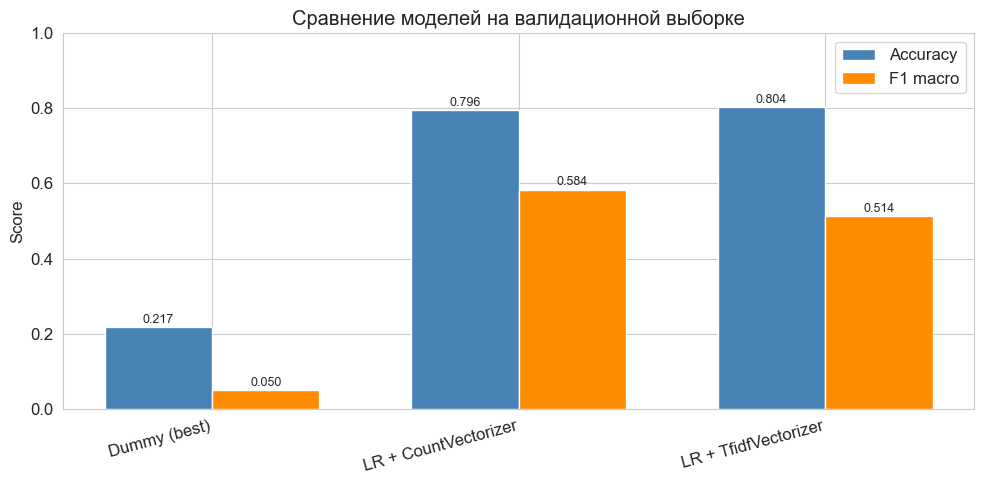

In [16]:
results = pd.DataFrame({
    'Model': ['Dummy (best)', 'LR + CountVectorizer', 'LR + TfidfVectorizer'],
    'Val Accuracy': [dummy_best_acc, count_val_acc, tfidf_val_acc],
    'Val F1 macro': [dummy_best_f1, count_val_f1, tfidf_val_f1],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results))
width = 0.35

bars1 = ax.bar(x - width / 2, results['Val Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width / 2, results['Val F1 macro'], width, label='F1 macro', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Сравнение моделей на валидационной выборке')
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.annotate(
            f'{bar.get_height():.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            fontsize=9,
        )

plt.tight_layout()
plt.show()

интересная ситуация - по accuracy TfidfVectorizer чуть лучше (0.804 vs 0.796), но по F1 macro CountVectorizer выигрывает (0.584 vs 0.514). видимо TF-IDF слишком сильно даунвейтит слова из редких классов. при этом CountVectorizer переобучается на трейне (0.9998 accuracy). попробую подобрать гиперпараметры для TF-IDF, может получится вытянуть F1.

## 6. подбор гиперпараметров на кросс-валидации

попробую подобрать гиперпараметры через `GridSearchCV`. беру за основу TF-IDF (по accuracy он чуть лучше на валидации). перебираю:
- `ngram_range` - (1,1) vs (1,2), биграммы могут помочь ловить устойчивые сочетания типа "ближний восток"
- `sublinear_tf` - логарифмическое масштабирование TF
- `C` - сила регуляризации

зафиксировал `max_features=30_000` и `min_df=3` чтобы не ждать вечность, и поменял солвер на `liblinear` - он сильно быстрее на разреженных данных. итого 12 комбинаций × 3 фолда = 36 фитов, метрика `f1_macro`.

In [17]:
pipe_tuned = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=30_000, min_df=3)),
    ('clf', LogisticRegression(
        max_iter=500,
        random_state=RANDOM_STATE,
        solver='liblinear',
    )),
])

param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'vectorizer__sublinear_tf': [True, False],
    'clf__C': [1.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipe_tuned,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid_search.fit(X_train, y_train)

print(f'\nЛучшие параметры:')
for param, value in sorted(grid_search.best_params_.items()):
    print(f'  {param}: {value}')
print(f'\nЛучший CV F1 macro: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Лучшие параметры:
  clf__C: 10.0
  vectorizer__ngram_range: (1, 2)
  vectorizer__sublinear_tf: True

Лучший CV F1 macro: 0.5515


In [18]:
best_model = grid_search.best_estimator_

best_val_acc = accuracy_score(y_val, best_model.predict(X_val))
best_val_f1 = f1_score(y_val, best_model.predict(X_val), average='macro')

print(f'Лучшая модель (после GridSearch) на валидации:')
print(f'  Accuracy: {best_val_acc:.4f}')
print(f'  F1 macro: {best_val_f1:.4f}')
print(f'\nУлучшение по F1 macro относительно базового TF-IDF: '
      f'{best_val_f1 - tfidf_val_f1:+.4f}')

Лучшая модель (после GridSearch) на валидации:
  Accuracy: 0.8206
  F1 macro: 0.5925

Улучшение по F1 macro относительно базового TF-IDF: +0.0786


## 7. оценка лучшей модели на тесте

теперь прогоняем лучшую модель на тестовой выборке - она вообще не участвовала ни в обучении, ни в подборе параметров, так что это честная оценка.

ок, грид серч нашел что лучше всего работают биграммы + sublinear_tf + C=10. F1 macro вырос с 0.51 до 0.59 - неплохой прирост. биграммы помогают ловить устойчивые выражения, а sublinear_tf сглаживает влияние сверхчастых слов. теперь проверим на тестовой выборке.

In [19]:
y_test_pred = best_model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f'Результаты на тестовой выборке:')
print(f'  Accuracy: {test_acc:.4f}')
print(f'  F1 macro: {test_f1:.4f}')
print(f'\nПодробный отчёт по классам:')
print(classification_report(y_test, y_test_pred))

Результаты на тестовой выборке:
  Accuracy: 0.8225
  F1 macro: 0.5783

Подробный отчёт по классам:
                   precision    recall  f1-score   support

                        0.00      0.00      0.00         5
   69-я параллель       0.90      0.26      0.41        34
       Библиотека       0.00      0.00      0.00         2
           Бизнес       0.71      0.32      0.44       200
      Бывший СССР       0.83      0.86      0.84      1445
              Дом       0.86      0.79      0.82       588
         Из жизни       0.70      0.59      0.64       747
   Интернет и СМИ       0.79      0.73      0.76      1209
             Крым       0.67      0.22      0.33        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.88      0.89      0.88      1455
          Легпром       0.00      0.00      0.00         3
              Мир       0.80      0.85      0.83      3697
  Наука и техника       0.83      0.87      0.85      1438
      Путешеств

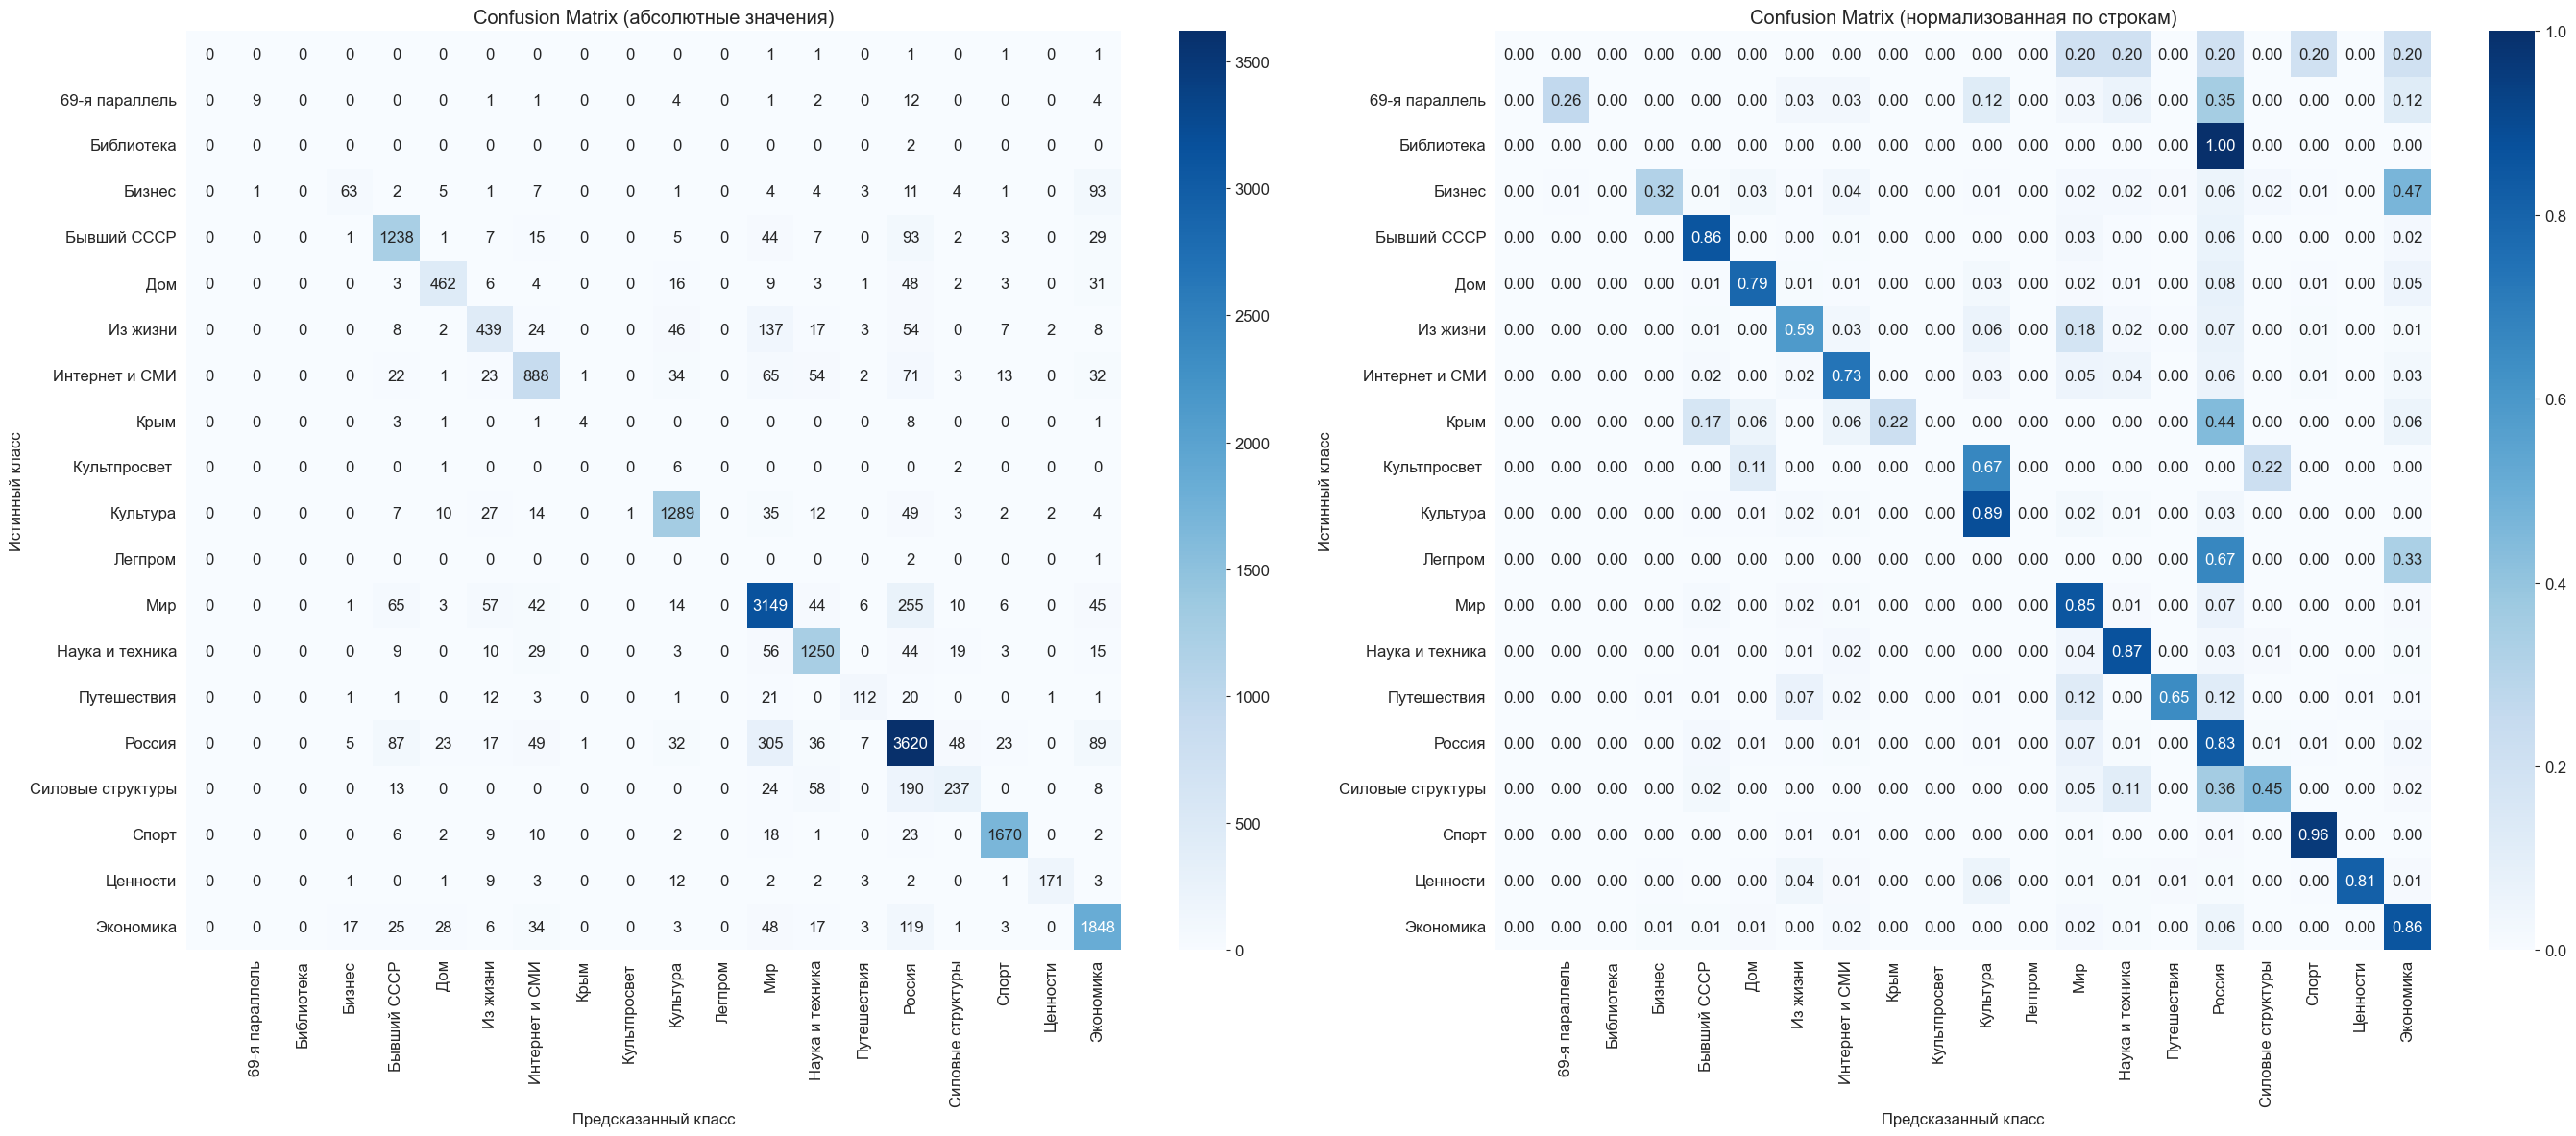

In [20]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels, ax=axes[0],
)
axes[0].set_title('Confusion Matrix (абсолютные значения)')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

sns.heatmap(
    cm_normalized, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=labels, yticklabels=labels, ax=axes[1],
)
axes[1].set_title('Confusion Matrix (нормализованная по строкам)')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

### анализ ошибок

посмотрим какие классы модель путает чаще всего

In [21]:
errors_mask = y_test.values != y_test_pred
errors_df = pd.DataFrame({
    'true_topic': y_test.values[errors_mask],
    'predicted_topic': y_test_pred[errors_mask],
    'text': X_test.values[errors_mask],
})

print(f'Всего ошибок: {errors_mask.sum()} из {len(y_test)} ({errors_mask.mean()*100:.1f}%)')

print(f'\nТоп-10 самых частых ошибочных пар (истинный -> предсказанный):')
error_pairs = (
    errors_df
    .groupby(['true_topic', 'predicted_topic'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
for (true_label, pred_label), count in error_pairs.items():
    print(f'  {true_label} -> {pred_label}: {count}')

Всего ошибок: 3551 из 20000 (17.8%)

Топ-10 самых частых ошибочных пар (истинный -> предсказанный):
  Россия -> Мир: 305
  Мир -> Россия: 255
  Силовые структуры -> Россия: 190
  Из жизни -> Мир: 137
  Экономика -> Россия: 119
  Бывший СССР -> Россия: 93
  Бизнес -> Экономика: 93
  Россия -> Экономика: 89
  Россия -> Бывший СССР: 87
  Интернет и СМИ -> Россия: 71


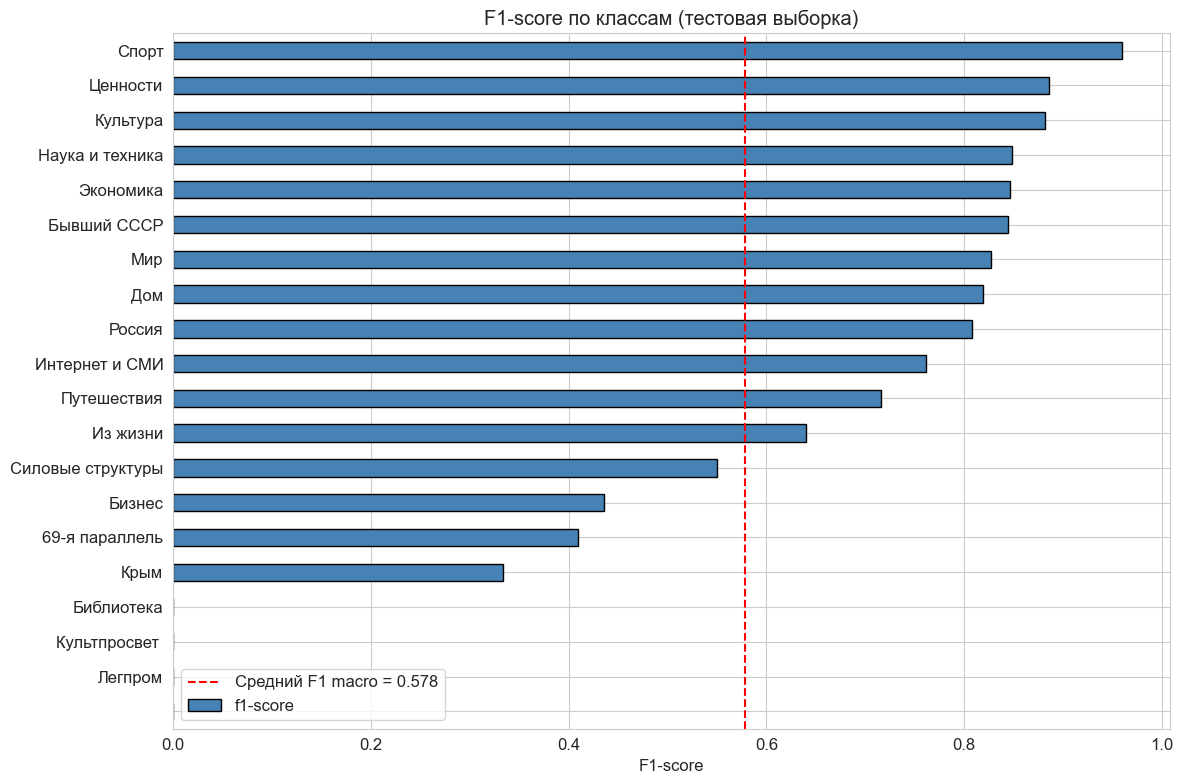

In [22]:
report_dict = classification_report(y_test, y_test_pred, output_dict=True)
class_metrics = pd.DataFrame(report_dict).T
class_metrics = class_metrics[class_metrics.index.isin(labels)]
class_metrics = class_metrics.sort_values('f1-score', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(6, len(labels) * 0.4)))
class_metrics['f1-score'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('F1-score по классам (тестовая выборка)')
ax.set_xlabel('F1-score')
ax.axvline(x=test_f1, color='red', linestyle='--', label=f'Средний F1 macro = {test_f1:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
top_error_pair = error_pairs.index[0]
pair_errors = errors_df[
    (errors_df['true_topic'] == top_error_pair[0])
    & (errors_df['predicted_topic'] == top_error_pair[1])
]

print(f'Примеры ошибок для самой частой пары: {top_error_pair[0]} -> {top_error_pair[1]}')
print('=' * 80)
for _, row in pair_errors.head(3).iterrows():
    print(f'Текст: {row["text"][:300]}...')
    print('-' * 80)

Примеры ошибок для самой частой пары: Россия -> Мир
Текст: российский мид назвать действие польша кощунственный выходка мид россия выразить возмущение связь инцидент произойти пятница август самолёт министр оборона сергей шойгу соответствовать заявление разместить сайт внешнеполитический ведомство город банска быстрица пройти торжество случай годовщина слов...
--------------------------------------------------------------------------------
Текст: дело убийство полицейский ольстер появиться третий обвинять обвинение дело убийство полицейский стивен кэррол ольстер предъявить третий человек сообщать март bbc news имя новый обвинять имя двое предыдущий называться сообщаться также возраст первый двое обвинять семнадцатилетний подросток летний муж...
--------------------------------------------------------------------------------
Текст: убийство загреб уволить хорватский министр шеф полиция премьер министр хорватия иво санадер ivo sanader принять решение уволить два министр шеф полиция загре

## 8. итоговая табличка

In [24]:
final_results = pd.DataFrame({
    'Model': [
        'Dummy (best)',
        'LR + CountVectorizer',
        'LR + TfidfVectorizer',
        'LR + TfidfVectorizer (tuned)',
    ],
    'Val Accuracy': [
        f'{dummy_best_acc:.4f}',
        f'{count_val_acc:.4f}',
        f'{tfidf_val_acc:.4f}',
        f'{best_val_acc:.4f}',
    ],
    'Val F1 macro': [
        f'{dummy_best_f1:.4f}',
        f'{count_val_f1:.4f}',
        f'{tfidf_val_f1:.4f}',
        f'{best_val_f1:.4f}',
    ],
    'Test Accuracy': ['-', '-', '-', f'{test_acc:.4f}'],
    'Test F1 macro': ['-', '-', '-', f'{test_f1:.4f}'],
})

print(final_results.to_string(index=False))

                       Model Val Accuracy Val F1 macro Test Accuracy Test F1 macro
                Dummy (best)       0.2171       0.0499             -             -
        LR + CountVectorizer       0.7964       0.5837             -             -
        LR + TfidfVectorizer       0.8040       0.5139             -             -
LR + TfidfVectorizer (tuned)       0.8206       0.5925        0.8225        0.5783


## 9. выводы

**что получилось:**

- dummy baseline ожидаемо показал мизерный F1 macro (~0.05) - при таком количестве классов угадывать самый частый бесполезно
- CountVectorizer дал F1 macro 0.58, TfidfVectorizer - 0.51. интересно, что по accuracy tfidf чуть лучше (0.804 vs 0.796), а вот по F1 macro хуже. видимо Count лучше справляется с редкими классами за счет того что не даунвейтит их характерные слова
- после подбора гиперпараметров на GridSearch лучшая модель (tfidf + биграммы + sublinear_tf + C=10) дала F1 macro 0.59 на валидации и 0.58 на тесте. прирост относительно базового tfidf - +0.08, неплохо
- на тесте accuracy 0.82, ошибок ~18%

**про ошибки:**

самая частая ошибка - модель путает "Россия" и "Мир". это логично, новости про международные отношения с участием России попадают и туда и туда, лексика очень похожая. вообще большинство ошибок между семантически близкими рубрками.

**про предобработку:**

остановился на пайплайне lowercase -> очистка регулярками -> лемматизация pymorphy3 -> стоп-слова. лемматизация лучше стемминга для русского (стеммер Snowball режет слова криво). кэширование лемм ускоряет обработку раз в 5-10, без него на 100к текстов пришлось бы ждать минут 5.

**что можно было бы улучшить:**

- попробовать SVM или градиентный бустинг
- обучить на полном датасете, а не на 100к
- использовать эмбеддинги (fasttext/word2vec) вместо bag-of-words
- может быть смержить похожие рубрики типа "Россия"/"Мир" в одну